In [2]:
from pytspl import list_datasets, load_dataset, SCPlot
import numpy as np
import matplotlib.pyplot as plt
from pytspl.embeddings.k_simplex2vec import cell2vec
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# list all the datasets
list_datasets()

['barcelona',
 'chicago-regional',
 'siouxfalls',
 'anaheim',
 'test_dataset',
 'goldcoast',
 'winnipeg',
 'chicago-sketch',
 'paper',
 'forex',
 'lastfm-1k-artist',
 'webkb-cornell',
 'webkb-texas',
 'webkb-wisconsin',
 'wsn']

In [7]:
dataset = "webkb-cornell"
cc, coordinates, flow = load_dataset(dataset=dataset, only_sc=True)

# 2. Choose which k-cells to embed
# k = 0 → nodes, 1 → edges, 2 → polygons (if any)
k = 1

emb_dim = 20
walk_length = 20
number_walks = 10
scheme = "uniform"          # or "uniform-lazy", "uniform-multicount"
laziness = None             # e.g. 0.5 if scheme == "uniform-lazy"
epochs = 10
seed = 0

# 3. Compute embeddings
embeddings = cell2vec(
    cc=cc,
    k=k,
    emb_dim=emb_dim,
    walk_length=walk_length,
    number_walks=number_walks,
    scheme=scheme,
    laziness=laziness,
    epochs=epochs,
    seed=seed,
    model_filename=None,    # don't bother saving model for now
)

print("Embeddings shape:", embeddings.shape)

Num. of nodes: 183
Num. of edges: 280
Num. of triangles: 59
Shape: (183, 280, 59)
Max Dimension: 2
Coordinates: 183
Flow: 0
Embeddings shape: (280, 20)


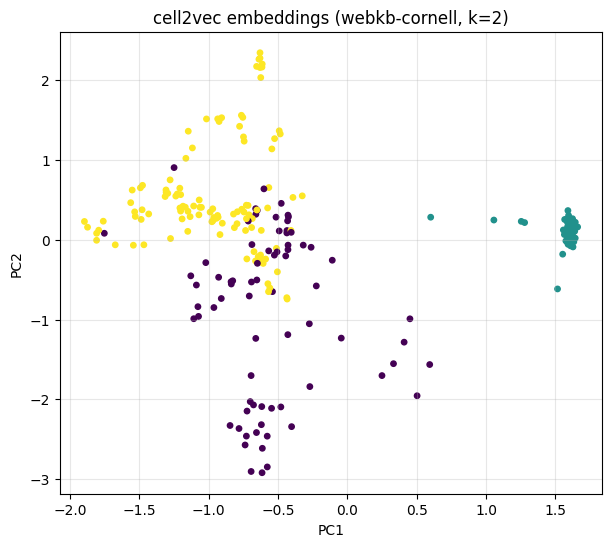

In [12]:
# 4. Cluster in embedding space
n_clusters = 3  # arbitrary; you can tune this
kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
labels = kmeans.fit_predict(embeddings)

# 5. PCA → 2D for visualization
pca = PCA(n_components=2, random_state=seed)
emb_2d = pca.fit_transform(embeddings)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, s=15)
plt.title(f"cell2vec embeddings ({dataset}, k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

In [9]:
for k in [0, 1, 2]:
    try:
        emb = cell2vec(
            cc=cc,
            k=k,
            emb_dim=16,
            walk_length=20,
            number_walks=10,
            scheme="uniform-multicount",
            laziness=None,
            epochs=5,
            seed=0,
            model_filename=None,
        )
        print(f"k={k}: emb.shape = {emb.shape}")
    except Exception as e:
        print(f"k={k}: failed with {e}")

k=0: emb.shape = (183, 16)
k=1: failed with probabilities are not non-negative
k=2: failed with probabilities are not non-negative


In [10]:
emb_lazy = cell2vec(
    cc=cc,
    k=1,
    emb_dim=16,
    walk_length=20,
    number_walks=10,
    scheme="uniform-lazy",
    laziness=0.5,
    epochs=5,
    seed=0,
    model_filename=None,
)
print("Lazy walk embeddings shape:", emb_lazy.shape)

Lazy walk embeddings shape: (280, 16)
